# 학습 관련 기술들

## 매개변수 갱신

- 신경망 학습의 목적 -> 손실 함수의 값을 가능한 낮추는 매개변수를 찾는 것
- - 매개변수의 최적값 찾기
- 이러한 문제를 푸는 것을 최적화(optimization)라 함

- 매개변수 공간은 매우 넓고 복잡해서 최적의 솔루션을 찾는 것은 쉽지 않음


- 지금까지는 최적의 매개변수 값을 찾는 단서로 매개변수의 기울기(미분)을 사용
- - 매개변수의 기울기를 구해, 기울어진 방향으로 매개변수 값을 갱신하는 일을 반복하여 최적 값에 다가감

- 이러한 방법을 '확률적 경사 하강법(SGD)'라 함



### 모험가 이야기

- 최적화를 해야하는 상황을 모험가 이야기에 비유

 - 최적 매개변수를 탐색한는 것도 모험가와 같이 어둠의 세계를 탐험하게 됨

 - 광대하고 복합한 지형을 지도도 없이 눈을 가린 채로 '깊은 곳'을 찾지 않으면 안됨


- 이 상황에서 중요한 단서가 되는 것은 땅의 '기울기'

- 지금 서 있는 장소에서 가장 크게 기울어진 방향으로 감 -> SDG의 전략
- 이 일을 반복하면 언젠가 '깊은 곳'에 찾아갈 수 있음

### 확률적 경사 하강법(SGD)

In [7]:
class SDG:
    def __init__(self, lr = 0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

- 초기화 때 받은 인수인 lr은 learning rate(학습률)

- 이 학습률을 인스턴스 변수로 유지
- update(params, grads) 메서드는 SGD 과정에서 반복해서 불림
- 인수인 params와 grads는 딕셔너리 변수
- params['W1'], grads['W1'] 등과 같이 각각 가중치 매개변수와 기울기를 저장

In [ ]:
# SGD 클래스를 사용하면 신경망 매개변수의 진행을 다음과 같이 수행 가능
# 동작하지 않는 코드

network = TwoLayerNet(...)
optimizer = SGD()

for i in range(10000):
    ...
    x_batch, t_batch = get_mini_batch(...) # 미니배치
    grads = network.gradient(x_batch, t_batch)
    params = network.params
    optimizer.update(params, grads)
    ...

- optimizer는 최적화를 행하는 자라는 뜻
- - 이 코드에서 SGD가 그 역할을 함

- 매개변수 갱신은 optimizer가 수행
- 우리는 optimizer에 매개변수와 기울기 정보를 넘겨주면 됨

- 이처럼 최적화를 담당하는 클래스를 분리해 구현하면 기능을 모듈화하기 좋음


- 대부분의 딥러닝 프레임워크는 다양한 최적화 기법을 구현해 제공하며, 원하는 기법으로 쉽게 바꿀 수 있는 구조로 됨

### SGD의 단점

- SGD는 단순하고 구현도 쉽지만, 문제에 따라서는 비효율적일 때가 있음

- 기울기는 y축 방향은 크고 x축 방향은 작음

- y축 방향은 가파름. x축 방향은 완만
- 

- SGD는 심하게 굽이진 움직임을 보여줌 -> 비효율적임

- SGD의 단점은 비등방성(anisotropy) 함수(방향에 따라 성질(기울기)가 달라지는 함수)에서는 탐색 경로가 비료율적
- SGD가 지그재그로 탐색하는 근본 원인은 기울어진 방향이 본래의 최솟값과 다른 방향을 가리켜서임

### 모멘텀

모멘텀(momentum)

- '운동량'
- 물리와 관계가 있음

- 기울기 방향으로 힘을 받아 물체가 가속된다는 물리 법칙을 나타냄

- 

In [9]:
class Momentum:
    def __init__(self, lr = 0.01, momentum = 0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeors_like(val)

        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]

- 인스턴스 변수 v가 물체의 속도

- v는 초기화 때는 아무 값도 담지 않고, 대신 update()가 처음 호출될 때 매개변수와 같은 구조의 데이터를 딕셔너리 변수로 저장

- 모멘텀의 갱신 경로는 공이 그릇 바닥을 구르듯 움직임
- - SGD와 비교하면 지그재그 정도가 덜함

- 이는 x축의 힘은 아주 작지만 방향을 변하지 않아서 한 방향으로 일정하게 가속하기 때문
- 거꾸로 y의 힘은 크지만 위아래로 번갈아 받아서 상충하여 y축 방향의 속도는 안정적이지 않음
- 전체적으로는 SGD보다 x축 방향으로 빠르게 다가가 지그재그 움직임이 줄어든다

### AdaGrad

- 신경망 학습에서는 학습률 값이 중요함

- 이 값이 너무 작으면 학습 시간이 길어지고, 반대로 너무 크면 발산하여 학습이 제대로 이뤄지지 않음

- 이 학습률을 정하는 효과적 기술로 '학습률 감소(learning rate decay)'가 있음

- 이는 학습을 진행하면서 학습률을 점차 줄어가는 방법
- 처음에는 크게 학습하다가 조금씩 작게 학습함

- 학습률을 서서히 낮추는 가장 간단한 방법은 매개변수 전치의 학습률 값을 일괄적으로 낮추는 것

- 이를 더욱 발전시킨 것이 AdaGrad
- AdaGrad는 각각의 매개변수에 맞춤형 값을 만들어줌

- AdaGrad는 개별 매개변수에 적응적으로(adaptive) 학습률을 조정하면서 학습 진행

- AdaGrad는 과거의 기울기를 제곱하여 계속 더해김

- 그래서 학습을 진행할수록 갱신 강도가 약해짐
- 실제로 무한히 계속 학습한다면 어느 순간 갱신량이 0이 되어 전혀 갱신되지 않게 됨
- 이 문제를 개선한 기법으로서 RMSProp방법이 있음
- RMSProp은 과거의 모든 기울기를 균일하게 더해가는 것이 아니라, 먼 과거의 기울기는 서서히 잊고 새로운 기울기 정보를 크게 반영함
- 이를 지수이동평균(Exponential Moving Average, EMA)라 하여, 과거 기울기의 반영 규모를 기하급수적으로 감소시킴

In [13]:
import numpy as np
class AdaGrad:
    def __init__(self, lr = 0.01):
        self.lr = lr
        self.h = None
    
    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

- 주의할 점은 마지막 줄에 1e-7이라는 작은 값을 더하는 부분

- 이 작은 값은 self.h[key]에 0이 담겨 있다 해도 0으로 나누는 사태를 막아줌
- 대부분의 딥러닝 프레임워크에서는 이 값도 인수로 설정 가능

- y축 방향은 기울기가 커서 처음에는 크게 움직이지만, 그 큰 움직임에 비례해 갱신 정도도 큰 폭으로 작아지도록 조정됨

- 그래서 y축 방향으로 갱신 강도가 빠르게 약해지고, 지그재그 움직임이 줄어든다

### Adam

- 모멘텀과 AdaGrad를 융합한 듯한 방법

- 이 두 방법의 이점을 조합했다면 매개변수 공간을 효율적으로 탐색
- 하이퍼파라미터의 '편향 보정'이 진행됨

- Adam의 갱신 과정도 그릇 바닥을 구르듯 움직임

- 모멘텀과 비슷한 패턴인데, 모멘텀 때보다 공의 좌우 흔들림이 적음
- 이는 학습의 갱신 강도를 적응적으로 조정해서 얻는 혜택

### 어느 갱신 방법을 이용할 것인가?

- 풀어야 할 문제가 무엇이냐에 따라 달라짐

- (학습률 등의) 하이퍼파라미터를 어떻게 설정하느냐에 따라서도 결과가 바뀜

- 모든 문제에서 항상 뛰어난 기법이라는 것은 아직까진 없음

### MNIST 데이터셋으로 본 갱신 방법 비교

- 이 실험은 각 층이 100개의 뉴런으로 구성된 5층 신경망에서 ReLU를 활성화 함수로는 사용해 측정

- 하이퍼파라미터인 학습률과 신경망의 구조(층 깊이 등)에 따라 결과가 달라짐

- 일반적으로 SGD보다 다른 세 기법이 빠르게 학습하고, 때로는 최종 정확도도 높게 나타남

### 가중치의 초깃값

- 신경망 학습에서 특히 중요한 것이 가중치의 초깃값

- 가중치의 초깃값을 무엇으로 설정하느냐가 신경망 학습의 성패가 가르는 일이 자주 일어남

### 초깃값을 0으로 하면?


- 오버피팅을 억제해 범용 성능을 높이는 테크닉인 '가중치 감소(weight decay)'

- 가중치 매개변수의 값이 작아지도록 학습하는 방법
- 가중치 값을 작게 하여 오버피팅이 일어나지 않게 하는 것

- 가중치를 작게 만들고 싶으면 초깃값도 최대한 작은 값에서 시작하는 것이 정공법

- 지금까지 가중치의 초깃값은 0.01 * np.random.randn(10, 100)처럼 정규분포에서 생성되는 값을 0.01배 한 작은 값을 사용

- 가중치를 0으로 설정하면? 

- 학습이 올바로 이뤄지지 않음!

- 초깃값을 0으로 하면 안되는 이유
- - 가중치를 균일한 값으로 설정하면 안됨

- 이유는 오차역전파법에서 모든 가중치의 값이 똑같이 갱신되기 떄문
- 가중치가 모두 똑같이 갱신되면 안됨

- 가중치들은 같은 초깃값에서 시작하고 갱신을 거쳐도 여전히 같은 값을 유지
- '가중치가 고르게 되어버리는 상황'을 막으려면 초깃값을 무작위로 설정해야 함

### 은닉층의 활성화값 분포

- 은닉층의 활성화값(활성화 함수의 출력 데이터)의 분포를 관찰하면 중요한 정보를 얻을 수 있음



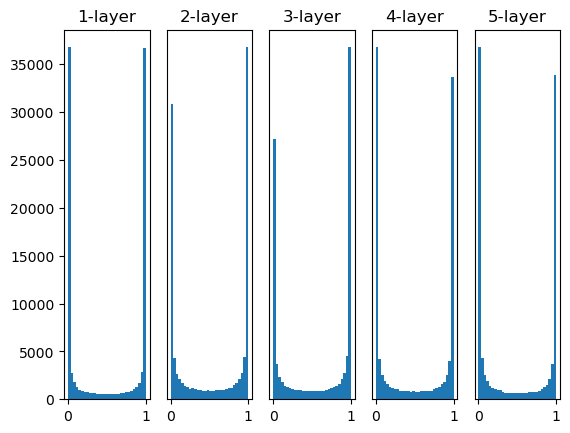

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLU(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)


x = np.random.randn(1000, 100) # 1000개의 데이터
node_num = 100 # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5 # 은닉층이 5개
activations = {} # 이곳에 활성화 결과(활성화 함수 저장)

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * 1

    a = np.dot(x, w)

    z = sigmoid(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])

    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

- 5개의 층

- 각 층의 뉴런은 100개씩

- 입력 데이터로서 1000개의 데이터를 정규분포로 무작위로 생성하여 5층 신경망에 흘림
- 활성화 함수로는 시그모이드 함수를 이용
- 각 층의 활성화 결과를 activations 변수에 저장
- 이 코드에서는 가중치의 분포에 주의해야 함
- 이번에는 표준편차가 1인 정규분포를 이용
- 이 분포된 정도(표준편차)를 바꿔가며 활성화값들의 분포가 어떻게 변화하는지 관찰하는 것이 목표

- 각 층의 활성화값들이 0과 1에 치우쳐 분포됨

- 여기서 사용한 시그모이드 함수는 그 출력이 0이나 1에 가까워지자 그 미분은 0에 다가감
- 그래서 데이터가 0과 1에 치우쳐 분포하게 되면 역전파 기울기 값이 점점 작아지다 사라짐
- 이것이 기울기 소실(gradient vanishing)
- 층을 깊게 하는 딥러닝에서 기울기 소실은 심각한 문제

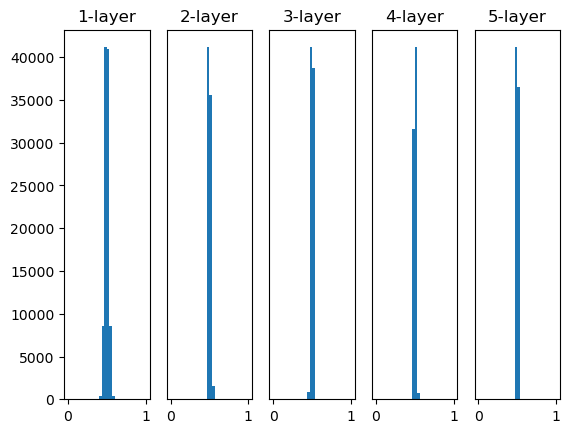

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLU(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)


x = np.random.randn(1000, 100) # 1000개의 데이터
node_num = 100 # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5 # 은닉층이 5개
activations = {} # 이곳에 활성화 결과(활성화 함수 저장)

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

# 가중치 표준편차 바꿔서 실험
    w = np.random.randn(node_num, node_num) * 0.01

    a = np.dot(x, w)

    z = sigmoid(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])

    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

- 이번에는 0.5 부근에 집중굄

- 기울기 소실 문제는 일어나지 않지만, 활성화 값들이 치우쳤다는 것은 표현력 관점에서는 큰 문제
- 이 상황에서는 다수의 뉴런이 거의 같은 값을 출력하고 있으니 뉴런을 여러 개 둔 의미가 없어짐
- 그래서 활성화 값들이 치우치면 '표현력을 제한'한다는 관점에서 문제가 됨

- 각 층의 활성화값은 적당히 고루 분포되어야 함

- 층과 층 사이에 적당하게 다양한 데이터가 흐르게 해야 신경망 학습이 효율적으로 이눠짐
- 치우친 데이터가 흐르면 기울기 소실이나 표현력 제한 문제에 빠져서 학습이 잘 이루어지지 않음

- Xavier 초깃값은 일반적인 딥러닝 프레임워크들이 표준적으로 이용하고 있음

- 카페(Cafe) 프레임워크는 가중치 초깃값을 설정할 때 인수로 xavier를 지정할 수 있음

- Xavier 초깃값을 사용하면 앞 층에 노드가 많을수록 대상 노드의 초깃값으로 설정하는 기중치가 좁게 퍼짐

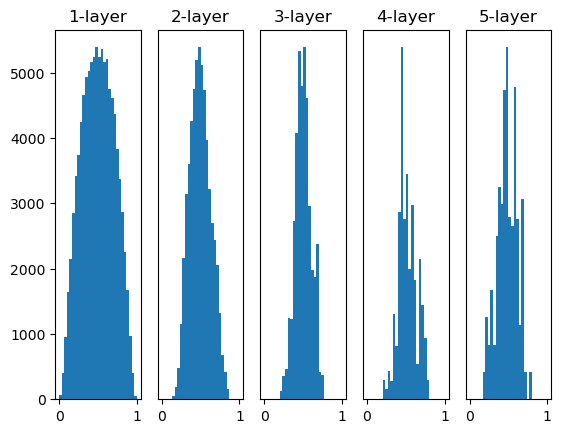

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLU(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)


x = np.random.randn(1000, 100) # 1000개의 데이터
node_num = 100 # 앞 층의 노드 수
hidden_layer_size = 5 # 은닉층이 5개
activations = {} # 이곳에 활성화 결과(활성화 함수 저장)

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

# 가중치 표준편차 바꿔서 실험
    w = np.random.randn(node_num, node_num) / np.sqrt(node_num)

    a = np.dot(x, w)

    z = sigmoid(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])

    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

- 층이 깊어지면서 형태가 다소 일그러지지만, 확실히 넓에 분포됨

- 각 층에 흐르는 데이터는 적당히 퍼져 있으므로, 시그모이드 함수의 표현력도 제한받지 않고 학습이 효율적으로 이뤄질 것으로 기대

### ReLU를 사용할 때의 가중치 초깃값

- Xavier 초깃값은 활성화 함수가 선형인 것을 전제로 이끈 결과

- sigmoid 함수와 tanh 함수는 좌우 대칭이라 중앙 부근이 선형인 함수로 볼 수 있음
- 그래서 Xavier 초깃값이 적당
- 반면 ReLU를 이용할 때는 ReLU에 특화된 초깃값을 이용하라고 권장 -> He 초깃값

- 신경망에 아주 작은 데이터가 흐른다는 것은 역전파 때 가중치의 기울기 역시 작아진다는 뜻

- 실제로도 학습이 거의 이뤄지지 않을 것

- 활성화 함수로 ReLU를 사용할 떄는 He 초깃값 사용

- sigmoid나 tanh 등의 S자 모양 곡선일 때는 Xavier 초깃값 사용